In [1]:
import torch
print(f"¿PyTorch detecta CUDA?: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("PyTorch sigue en modo CPU. Verifica los drivers de NVIDIA.")

¿PyTorch detecta CUDA?: True
GPU detectada: NVIDIA GeForce RTX 4070 Ti


In [2]:
# TÍTULO: Entrenamiento Comparativo - YOLOv8 vs Custom CNN (OCR)
# OBJETIVO: Entrenar y comparar dos arquitecturas para clasificación de caracteres.

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from ultralytics import YOLO
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from datetime import datetime
from tqdm.notebook import tqdm
from PIL import Image

# --- CONFIGURACIÓN DE HARDWARE ---
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"GPU Activa: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device('cpu')
    print("ALERTA: Usando CPU. El entrenamiento será lento.")

# --- RUTAS ---
# Dataset generado en el paso anterior
DATASET_DIR = '../../datasets/03_caracteres' 
# Carpeta para guardar ambos modelos
PROJECT_DIR = '../../models/03_caracteres/custom_cnn'
os.makedirs(PROJECT_DIR, exist_ok=True)

# Parámetros Globales
IMG_SIZE = 128      # Tamaño de entrada (caracteres son pequeños)
BATCH_SIZE = 256
EPOCHS = 100        # Suficiente para caracteres simples
NUM_CLASSES = 34   # A-Z (23) + 0-9 (10) - 3 (caracteres especiales)

print("Entorno listo.")

PyTorch Version: 2.5.1+cu121
GPU Activa: NVIDIA GeForce RTX 4070 Ti
Entorno listo.


In [3]:
import cv2
import numpy as np

def preprocesar_entrenamiento(img_pil):
    # Convertir a array de numpy
    img = np.array(img_pil)
    gris = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Binarización Adaptativa (mismo que en tu pipeline actual)
    binaria = cv2.adaptiveThreshold(
        gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 11, 2
    )
    
    # Dilatación leve para engrosar trazos (ayuda a la "pata" de la R)
    kernel = np.ones((2,2), np.uint8)
    binaria = cv2.dilate(binaria, kernel, iterations=1)
    
    # Redimensionar a 128x128
    binaria = cv2.resize(binaria, (128, 128), interpolation=cv2.INTER_AREA)
    
    # Regresar a formato PIL para las transformaciones de PyTorch
    return Image.fromarray(cv2.cvtColor(binaria, cv2.COLOR_GRAY2RGB))

In [4]:
# Transformaciones para la CNN Custom (Normalización estándar)
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(preprocesar_entrenamiento), 
    transforms.RandomRotation(5),                 
    transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalización estándar
])

# Cargar Datasets usando ImageFolder (detecta carpetas A, B, C...)
train_dir = os.path.join(DATASET_DIR, 'train')
val_dir = os.path.join(DATASET_DIR, 'val')

# Verificación de seguridad
if not os.path.exists(train_dir):
    raise FileNotFoundError(f"No se encuentra el dataset en {train_dir}")

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Guardar nombres de clases
CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Datos cargados:")
print(f"   - Clases ({NUM_CLASSES}): {CLASS_NAMES[:]}")
print(f"   - Train images: {len(train_dataset)}")
print(f"   - Val images:   {len(val_dataset)}")

Datos cargados:
   - Clases (34): ['-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
   - Train images: 198295
   - Val images:   49585


In [8]:
print("\Entrenando YOLOv11 Nano (Classifier)...")

PROJECT_DIR_REL = '../../models/03_caracteres'
PROJECT_DIR = os.path.abspath(PROJECT_DIR_REL)

# Nombre del experimento YOLO
run_name_yolo_extensed = "103_ocr_yolo_11n"

# Cargar modelo
model_yolo11 = YOLO('yolo11n-cls.pt')

# Entrenar
start_time = time.time()
results_yolo = model_yolo11.train(
    data=DATASET_DIR,
    project=PROJECT_DIR,
    name=run_name_yolo_extensed,
    epochs=100,
    patience=25,
    imgsz=128,
    batch=512,    
    pretrained=True,
    optimizer='AdamW',
    lr0=0.001,
    device=0 if torch.cuda.is_available() else 'cpu',
    verbose=True
)
yolo_train_time = time.time() - start_time

print(f"YOLO entrenamiento completado en {yolo_train_time:.2f} segundos.")

\Entrenando YOLOv11 Nano (Classifier)...
New https://pypi.org/project/ultralytics/8.4.128 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.116 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11873MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=512, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../datasets/03_caracteres, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00

/home/robertoplr/miniconda3/envs/proyecto/lib/python3.10/site-packages/ultralytics/utils/tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  sx = feats[0].new_full((w,), 1, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
/home/robertoplr/miniconda3/envs/proyecto/lib/python3.10/site-packages/ultralytics/utils/tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at ../aten/src/ATen/Context.cpp:91.)
  sy = feat

train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 71.2±39.3 MB/s, size: 1.1 KB)
train: Scanning /home/robertoplr/Documentos/moca_proyecto/datasets/03_caracteres/train... 198295 images, 0 corrupt: 100% ━━━━━━━━━━━━ 198295/198295 52.0Git/s 0.0s
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 44.8±17.6 MB/s, size: 1.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /home/robertoplr/Documentos/moca_proyecto/datasets/03_caracteres/val... 49585 images, 0 corrupt: 100% ━━━━━━━━━━━━ 49585/49585 2.6Git/s 0.0s
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.004), 40 bias(decay=0.0)
Image sizes 128 train, 128 val
Using 8 dataloader workers
Logging results to /home/robertoplr/Documentos/moca_proyecto/models/03_caracteres/103_ocr_yolo_11n
Starting training for 100 epochs...

      Epoch    GPU_mem       loss  Insta

In [9]:
class CustomOCR_CNN(nn.Module):
    def __init__(self, num_classes=34): # Corregido a 34 clases
        super(CustomOCR_CNN, self).__init__()
        
        # Entrada esperada: 3x128x128
        
        # Bloque Convolucional 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Salida: 32x64x64
        )        
        
        # Bloque Convolucional 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Salida: 64x32x32
        )       

        # Bloque Convolucional 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Salida: 128x16x16
        )
        
        # NUEVO: Bloque Convolucional 4 (Control de dimensionalidad)
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Salida: 256x8x8
        )
        
        # Clasificador (Fully Connected)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512), # Perfectamente adaptado al nuevo bloque
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.fc(x)
        return x

In [10]:
import sys
!{sys.executable} -m pip install ipywidgets tqdm

In [11]:
# Ejecuta esto en tu notebook de entrenamiento
print(train_loader.dataset.class_to_idx)

{'-': 0, '0': 1, '1': 2, '2': 3, '3': 4, '4': 5, '5': 6, '6': 7, '7': 8, '8': 9, '9': 10, 'A': 11, 'B': 12, 'C': 13, 'D': 14, 'E': 15, 'F': 16, 'G': 17, 'H': 18, 'J': 19, 'K': 20, 'L': 21, 'M': 22, 'N': 23, 'P': 24, 'R': 25, 'S': 26, 'T': 27, 'U': 28, 'V': 29, 'W': 30, 'X': 31, 'Y': 32, 'Z': 33}


In [12]:
print("\nEntrenando CNN Personalizada con Early Stopping...")

# 1. Instanciar modelo (asegúrate de que NUM_CLASSES sea 33)
cnn_model = CustomOCR_CNN(num_classes=NUM_CLASSES).to(DEVICE)

# 2. Configuración
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# 3. Variables de Early Stopping y Control
patience = 25  # Épocas a esperar antes de detenerse
counter = 0
best_val_loss = float('inf')
cnn_save_path = os.path.join(PROJECT_DIR, 'custom_cnn_best.pth')

# Historial
cnn_history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

start_time = time.time()

for epoch in range(EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    cnn_model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = cnn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    # --- FASE DE VALIDACIÓN (Crucial para Early Stopping) ---
    cnn_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for v_inputs, v_labels in val_loader: # Asegúrate de tener definido val_loader
            v_inputs, v_labels = v_inputs.to(DEVICE), v_labels.to(DEVICE)
            v_outputs = cnn_model(v_inputs)
            v_loss = criterion(v_outputs, v_labels)
            
            val_loss += v_loss.item()
            _, v_predicted = v_outputs.max(1)
            val_total += v_labels.size(0)
            val_correct += v_predicted.eq(v_labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = val_correct / val_total

    # Guardar historial
    cnn_history['loss'].append(epoch_loss)
    cnn_history['acc'].append(epoch_acc)
    cnn_history['val_loss'].append(epoch_val_loss)
    cnn_history['val_acc'].append(epoch_val_acc)
    
    print(f"   Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.4f} | Val_Loss={epoch_val_loss:.4f}, Val_Acc={epoch_val_acc:.4f}")

    # --- LÓGICA DE EARLY STOPPING ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(cnn_model.state_dict(), cnn_save_path) # Guarda solo el mejor
        counter = 0
        print(f"Nuevo mejor modelo guardado en: {cnn_save_path}")
    else:
        counter += 1
        print(f"Sin mejora en validación. Paciencia: {counter}/{patience}")
        
    if counter >= patience:
        print(f"Deteniendo entrenamiento en la época {epoch+1}. El modelo óptimo está guardado.")
        break

cnn_train_time = time.time() - start_time
print(f"\nProceso completado en {cnn_train_time:.2f} segundos.")


Entrenando CNN Personalizada con Early Stopping...


Epoch 1/100:   0%|          | 0/775 [00:00<?, ?it/s]

   Epoch 1: Loss=1.8909, Acc=0.4439 | Val_Loss=0.3734, Val_Acc=0.9115
Nuevo mejor modelo guardado en: /home/robertoplr/Documentos/moca_proyecto/models/03_caracteres/custom_cnn_best.pth


Epoch 2/100:   0%|          | 0/775 [00:00<?, ?it/s]

   Epoch 2: Loss=1.0077, Acc=0.6451 | Val_Loss=0.1851, Val_Acc=0.9590
Nuevo mejor modelo guardado en: /home/robertoplr/Documentos/moca_proyecto/models/03_caracteres/custom_cnn_best.pth


...

   Epoch 52: Loss=0.2406, Acc=0.9214 | Val_Loss=0.0444, Val_Acc=0.9910
Sin mejora en validación. Paciencia: 23/25


Epoch 53/100:   0%|          | 0/775 [00:00<?, ?it/s]

   Epoch 53: Loss=0.2389, Acc=0.9219 | Val_Loss=0.0435, Val_Acc=0.9911
Sin mejora en validación. Paciencia: 24/25


Epoch 54/100:   0%|          | 0/775 [00:00<?, ?it/s]

   Epoch 54: Loss=0.2362, Acc=0.9230 | Val_Loss=0.0481, Val_Acc=0.9910
Sin mejora en validación. Paciencia: 25/25
Deteniendo entrenamiento en la época 54. El modelo óptimo está guardado.

Proceso completado en 19219.95 segundos.


In [13]:
# Cargando el modelo entrenado para inferencia

import torch

# 1. Importa la clase de tu arquitectura (asegúrate de que el nombre coincida con tu código)
# Si la clase está en otro archivo .py, impórtala. Si la definiste en el mismo cuaderno, omite esta línea.
# from tu_archivo_script import CustomOCR_CNN 

# 2. Instancia la arquitectura estableciendo estrictamente nuestras 34 clases
cnn_model = CustomOCR_CNN(num_classes=34)

# 3. Define la ruta donde se guardaron los pesos de tu mejor época (usualmente .pth o .pt)
ruta_pesos = '../../models/03_caracteres/custom_cnn/custom_cnn_best.pth'

# 4. Carga el diccionario de estados (pesos) en la arquitectura
cnn_model.load_state_dict(torch.load(ruta_pesos, map_location=torch.device('cuda')))

# 5. Mueve el modelo a la tarjeta gráfica y pásalo a MODO EVALUACIÓN
cnn_model.to('cuda')
cnn_model.eval()

print("Red Custom OCR cargada exitosamente en la GPU y lista para inferencia.")

Red Custom OCR cargada exitosamente en la GPU y lista para inferencia.


/tmp/ipykernel_4208/304292245.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn_model.load_state_dict(torch.load(ruta_pesos, map_location=torch.device('cuda')))


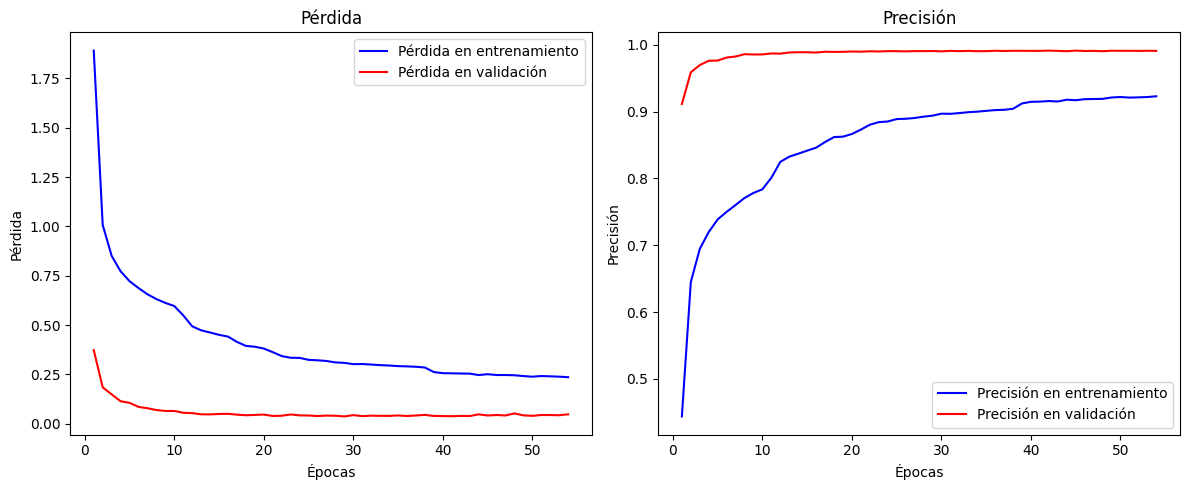

In [14]:
import matplotlib.pyplot as plt

%matplotlib inline

def graficar_entrenamiento(history):
    epochs = range(1, len(history['loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Gráfica de Pérdida (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], 'b-', label='Pérdida en entrenamiento')
    plt.plot(epochs, history['val_loss'], 'r-', label='Pérdida en validación')
    plt.title('Pérdida')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    
    # Gráfica de Precisión (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['acc'], 'b-', label='Precisión en entrenamiento')
    plt.plot(epochs, history['val_acc'], 'r-', label='Precisión en validación')
    plt.title('Precisión')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Llamada al terminar el entrenamiento
graficar_entrenamiento(cnn_history)

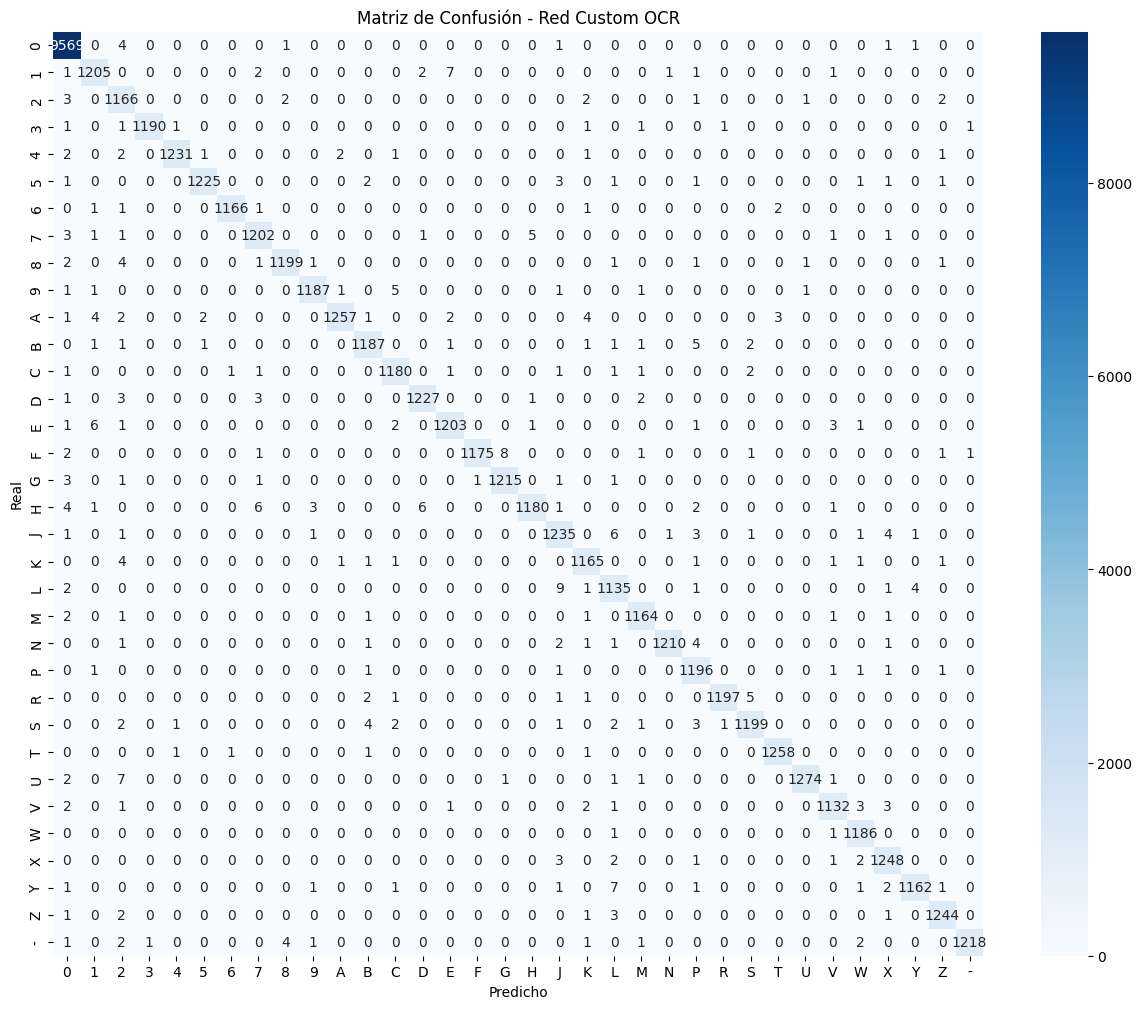


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9577
           1       0.99      0.99      0.99      1220
           2       0.97      0.99      0.98      1177
           3       1.00      0.99      1.00      1197
           4       1.00      0.99      0.99      1241
           5       1.00      0.99      0.99      1236
           6       1.00      0.99      1.00      1172
           7       0.99      0.99      0.99      1215
           8       0.99      0.99      0.99      1211
           9       0.99      0.99      0.99      1198
           A       1.00      0.99      0.99      1276
           B       0.99      0.99      0.99      1201
           C       0.99      0.99      0.99      1189
           D       0.99      0.99      0.99      1237
           E       0.99      0.99      0.99      1219
           F       1.00      0.99      0.99      1190
           G       0.99      0.99      0.99      1223


In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def generar_reportes_finales(model, loader, classes):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    # 1. Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Matriz de Confusión - Red Custom OCR')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()
    
    # 2. Reporte de Clasificación (Precision, Recall, F1-Score)
    print("\nReporte de Clasificación:")
    print(classification_report(y_true, y_pred, target_names=classes))
    
# CORRECTO
# 1. Definimos la cadena en el mismo orden que el entrenamiento
CHARS = "0123456789ABCDEFGHJKLMNPRSTUVWXYZ-"

# 2. La función list() la rompe y la convierte en un arreglo de 34 elementos
etiquetas_lista = list(CHARS)

# Ejecución (usa tu lista de 33 caracteres extraída del dataset)
generar_reportes_finales(cnn_model, val_loader, etiquetas_lista)

In [16]:
def contar_parametros(modelo):
    # Parámetros totales (incluye los que no se entrenan)
    totales = sum(p.numel() for p in modelo.parameters())
    # Parámetros entrenables (los que realmente se actualizan)
    entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    
    print(f"Número total de parámetros: {totales:,}")
    print(f"Número de parámetros entrenables: {entrenables:,}")

# Uso con tu red custom
contar_parametros(cnn_model)

Número total de parámetros: 8,795,938
Número de parámetros entrenables: 8,795,938


In [17]:
!pip install torchsummary

In [18]:
from torchsummary import summary

# El segundo argumento es la forma de entrada (C, H, W) 
# En tu caso es (3, 128, 128) porque usas RGB y redimensión a 128x128
summary(cnn_model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
         MaxPool2d-4           [-1, 32, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          18,496
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
         MaxPool2d-8           [-1, 64, 32, 32]               0
            Conv2d-9          [-1, 128, 32, 32]          73,856
      BatchNorm2d-10          [-1, 128, 32, 32]             256
             ReLU-11          [-1, 128, 32, 32]               0
        MaxPool2d-12          [-1, 128, 16, 16]               0
           Conv2d-13          [-1, 256, 16, 16]         295,168
      BatchNorm2d-14          [-1, 256,

In [19]:
# Rutas a los archivos guardados 
run_name_yolo = f"103_ocr_yolo_11n"
YOLO_WEIGHTS = os.path.join(PROJECT_DIR, run_name_yolo, 'weights', 'best.pt') 
CNN_WEIGHTS = os.path.join(PROJECT_DIR, 'custom_cnn_best.pth')

print(f"Cargando YOLO desde: {YOLO_WEIGHTS}")
print(f"Cargando CNN desde: {CNN_WEIGHTS}")

Cargando YOLO desde: /home/robertoplr/Documentos/moca_proyecto/models/03_caracteres/103_ocr_yolo_11n/weights/best.pt
Cargando CNN desde: /home/robertoplr/Documentos/moca_proyecto/models/03_caracteres/custom_cnn_best.pth


In [20]:
# 1. Instanciar la arquitectura 
loaded_cnn = CustomOCR_CNN(num_classes=NUM_CLASSES).to(DEVICE)

# 2. Cargar el diccionario de pesos
try:
    state_dict = torch.load(CNN_WEIGHTS)
    
    # 3. Inyectar los pesos al esqueleto
    loaded_cnn.load_state_dict(state_dict)
    
    # 4. Poner en modo evaluación (Congela Dropout y BatchNorm)
    loaded_cnn.eval()
    
    print("Modelo CNN cargado exitosamente.")
    
    cnn_train_time = 3416.40
except Exception as e:
    print(f"Error cargando CNN: {e}")

Modelo CNN cargado exitosamente.


/tmp/ipykernel_4208/4258484010.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(CNN_WEIGHTS)


In [21]:
def evaluate_model(model, loader, model_type='cnn'):
    model.eval() # Modo evaluación (importante para Dropout/BatchNorm)
    all_preds = []
    all_labels = []
    inference_times = []
    
    print(f"Evaluando {model_type}...")
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader):
            # Preparar inputs según modelo
            if model_type == 'cnn':
                inputs = inputs.to(DEVICE)
            else:
                # YOLO espera rutas de archivos o arrays numpy, pero aquí
                # estamos pasando tensores. Para ser justos en velocidad,
                # usaremos el método .predict() de YOLO en lote si es posible,
                # o convertiremos. Para simplificar, usaremos validación integrada de YOLO arriba
                # y aquí solo mediremos CNN, luego uniremos datos.
                pass 

            if model_type == 'cnn':
                start = time.time()
                outputs = model(inputs)
                end = time.time()
                
                _, predicted = outputs.max(1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
                
                # Tiempo por batch -> Tiempo por imagen
                inference_times.append((end - start) / inputs.size(0))

    if model_type == 'cnn':
        acc = accuracy_score(all_labels, all_preds)
        avg_inference_ms = (sum(inference_times) / len(inference_times)) * 1000
        return acc, avg_inference_ms




In [22]:
# Cargando el modelo de yolo
run_name = f"103_ocr_yolo_11n"

MODEL_DIR = '../../models/03_caracteres'

# Cargar el MEJOR modelo resultante del entrenamiento anterior
model_yolo11n = os.path.join(MODEL_DIR, run_name, 'weights', 'best.pt')
model_yolo = YOLO(model_yolo11n)

yolo_train_time = 0.714*3600000

Evaluando cnn...


  0%|          | 0/194 [00:00<?, ?it/s]

Ultralytics 8.4.116 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11873MiB)
YOLO11n-cls summary (fused): 47 layers, 1,569,578 parameters, 0 gradients, 3.2 GFLOPs
train: /home/robertoplr/Documentos/moca_proyecto/datasets/03_caracteres/train... found 198295 images in 34 classes ✅ 
val: /home/robertoplr/Documentos/moca_proyecto/datasets/03_caracteres/val... found 49585 images in 34 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 71.5±21.2 MB/s, size: 1.1 KB)
val: Scanning /home/robertoplr/Documentos/moca_proyecto/datasets/03_caracteres/val... 49585 images, 0 corrupt: 100% ━━━━━━━━━━━━ 49585/49585 7.4Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3100/3100 263.1it/s 11.8s0.1s
                   all      0.985          1
Speed: 0.0ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /home/robertoplr/Documentos/moca_proyecto/notebooks/03_caracteres/runs/classify/val

TABLA DE R

,Modelo,Accuracy (Top-1),Tiempo Entrenamiento (s),Velocidad Inferencia (ms/img)
0,YOLOv8n-CLS,0.984653,2570400.0,0.203144
1,Custom CNN,0.990824,3416.4,0.003682


/tmp/ipykernel_4208/3746691427.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Modelo', y='Accuracy (Top-1)', ax=ax[0], palette='viridis')
/tmp/ipykernel_4208/3746691427.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Modelo', y='Velocidad Inferencia (ms/img)', ax=ax[1], palette='rocket')
/tmp/ipykernel_4208/3746691427.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Modelo', y='Tiempo Entrenamiento (s)', ax=ax[2], palette='magma')


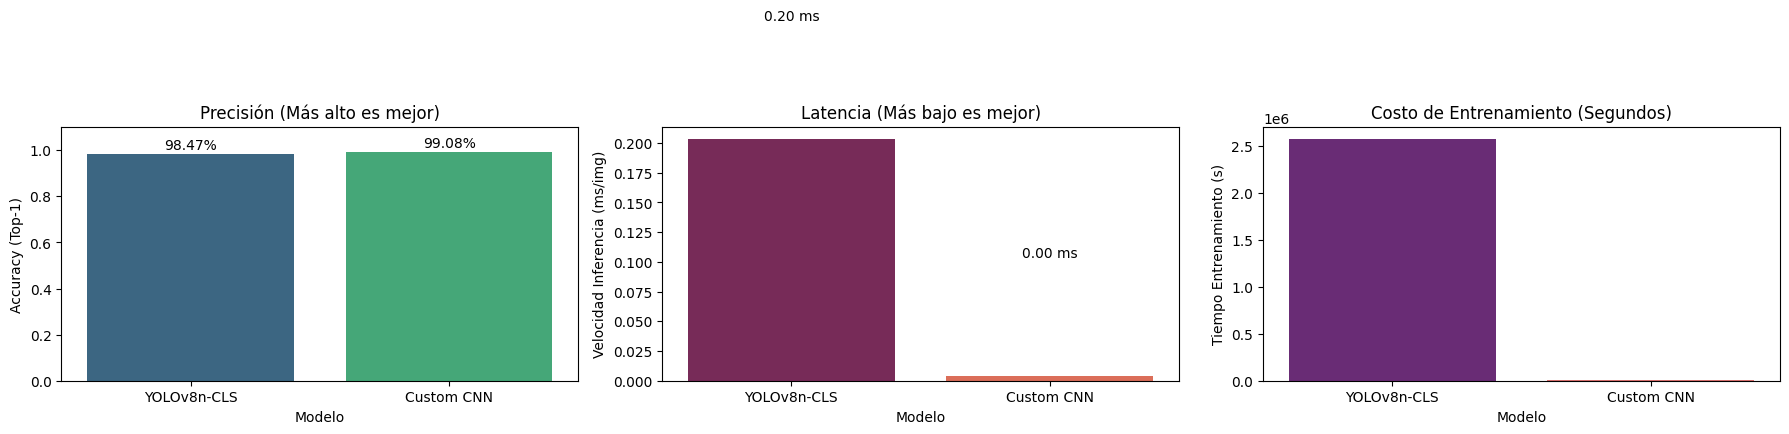

In [23]:
# 1. Evaluar CNN
# cnn_acc, cnn_speed = evaluate_model(cnn_model, val_loader, 'cnn')
cnn_acc, cnn_speed = evaluate_model(loaded_cnn, val_loader, 'cnn')

# 2. Obtener métricas de YOLO (del objeto results)
# YOLO calcula esto automáticamente al entrenar
yolo_metrics = model_yolo.val()
yolo_acc = yolo_metrics.top1
yolo_speed = yolo_metrics.speed['inference'] # ms per image

# --- REPORTE FINAL ---
comparison_data = {
    'Modelo': ['YOLOv8n-CLS', 'Custom CNN'],
    'Accuracy (Top-1)': [yolo_acc, cnn_acc],
    'Tiempo Entrenamiento (s)': [yolo_train_time, cnn_train_time],
    'Velocidad Inferencia (ms/img)': [yolo_speed, cnn_speed]
}

df_results = pd.DataFrame(comparison_data)

print("\nTABLA DE RESULTADOS:")
display(df_results)

# Graficar
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: Accuracy
sns.barplot(data=df_results, x='Modelo', y='Accuracy (Top-1)', ax=ax[0], palette='viridis')
ax[0].set_title('Precisión (Más alto es mejor)')
ax[0].set_ylim(0, 1.1)
for i, v in enumerate(df_results['Accuracy (Top-1)']):
    ax[0].text(i, v + 0.02, f"{v:.2%}", ha='center')

# Gráfica 2: Velocidad
sns.barplot(data=df_results, x='Modelo', y='Velocidad Inferencia (ms/img)', ax=ax[1], palette='rocket')
ax[1].set_title('Latencia (Más bajo es mejor)')
for i, v in enumerate(df_results['Velocidad Inferencia (ms/img)']):
    ax[1].text(i, v + 0.1, f"{v:.2f} ms", ha='center')

# Gráfica 3: Tiempo Entrenamiento
sns.barplot(data=df_results, x='Modelo', y='Tiempo Entrenamiento (s)', ax=ax[2], palette='magma')
ax[2].set_title('Costo de Entrenamiento (Segundos)')

plt.tight_layout()
plt.show()

In [24]:
model_yolo.info()

YOLO11n-cls summary (fused): 47 layers, 1,569,578 parameters, 0 gradients, 3.2 GFLOPs


(47, 1569578, 0, 3.2321408)

In [25]:
print("\n--- INICIANDO EVALUACIÓN COMPARATIVA ---")

# 1. Evaluar CNN Propia
# Pasamos el objeto cargado 'loaded_cnn' y el string 'cnn'
acc_cnn, lat_cnn = evaluate_model(loaded_cnn, val_loader, model_type='cnn')

print(f"\nResultados CNN Personalizada:")
print(f"   • Accuracy: {acc_cnn:.4f}")
print(f"   • Latencia: {lat_cnn:.4f} ms")

# 2. Evaluar YOLOv8
# YOLO tiene su propio método .val() que es más robusto para métricas internas,
# pero si quieres usar tu función 'evaluate_model' para medir tiempo en igualdad de condiciones:

# Opción A: Usar método nativo de YOLO (Recomendado para Accuracy)
metrics_yolo = model_yolo.val(data=DATASET_DIR, verbose=False)
acc_yolo = metrics_yolo.top1
# La velocidad la sacamos del objeto metrics
lat_yolo = metrics_yolo.speed['inference'] 

print(f"\nResultados YOLOv8n:")
print(f"   • Accuracy: {acc_yolo:.4f}")
print(f"   • Latencia: {lat_yolo:.4f} ms")

# --- COMPARACIÓN FINAL ---
print("\nVERDICTO FINAL:")
if lat_cnn < lat_yolo:
    diff = lat_yolo / lat_cnn
    print(f"Tu CNN es {diff:.1f}x veces más rápida que YOLO.")
else:
    print(f"YOLO es más rápido.")

if acc_cnn > acc_yolo:
    print(f"Tu CNN es más precisa.")
else:
    diff_acc = (acc_yolo - acc_cnn) * 100
    print(f"Tu CNN es un {diff_acc:.2f}% menos precisa (Trade-off aceptable).")


--- INICIANDO EVALUACIÓN COMPARATIVA ---
Evaluando cnn...


  0%|          | 0/194 [00:00<?, ?it/s]


Resultados CNN Personalizada:
   • Accuracy: 0.9910
   • Latencia: 0.0037 ms
Ultralytics 8.4.116 🚀 Python-3.10.20 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti, 11873MiB)
train: /home/robertoplr/Documentos/moca_proyecto/datasets/03_caracteres/train... found 198295 images in 34 classes ✅ 
val: /home/robertoplr/Documentos/moca_proyecto/datasets/03_caracteres/val... found 49585 images in 34 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 68.0±13.4 MB/s, size: 1.1 KB)
val: Scanning /home/robertoplr/Documentos/moca_proyecto/datasets/03_caracteres/val... 49585 images, 0 corrupt: 100% ━━━━━━━━━━━━ 49585/49585 11.6Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3100/3100 257.1it/s 12.1s0.0s
                   all      0.985          1
Speed: 0.0ms preprocess, 0.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /home/robertoplr/Documentos/moca_proyecto/notebooks/03_caracteres/runs/classify/val-2

Resultados YOLO